# KMeans Clustering & KBest Feature Selection

This notebook demonstrates two unsupervised/statistical techniques for feature engineering and selection:

| Technique | Purpose |
|---|---|
| **KMeans Clustering** | Groups rows into clusters based on numerical features; the cluster label becomes a new engineered feature |
| **SelectKBest (f_classif)** | Ranks features by their ANOVA F-score against the target variable and selects the top-K most informative ones |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Data Quality Check

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


## 4. KMeans Clustering

### 4.1 Scale Features & Fit KMeans

KMeans is distance-based, so features must be standardised first. We cluster on `Cost_of_the_Product` and `Weight_in_gms` with **k = 3**.

In [4]:
X = df[['Cost_of_the_Product', 'Weight_in_gms']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[-0.17723165  0.78610246]
 [ 0.96278799 -0.91798321]
 [-1.10436051 -1.15312397]]


### 4.2 Cluster Profiles — Average Feature Values

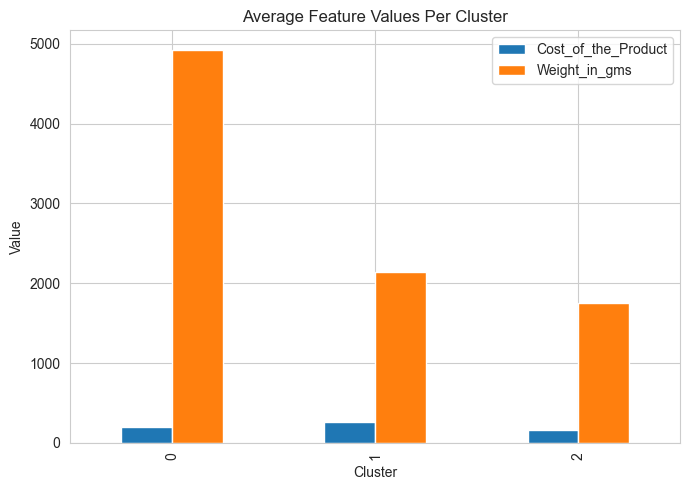

In [5]:
cluster_summary = df.groupby('Cluster')[['Cost_of_the_Product', 'Weight_in_gms']].mean()

cluster_summary.plot(kind='bar', figsize=(7, 5))
plt.title("Average Feature Values Per Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

### 4.3 Cluster Distribution

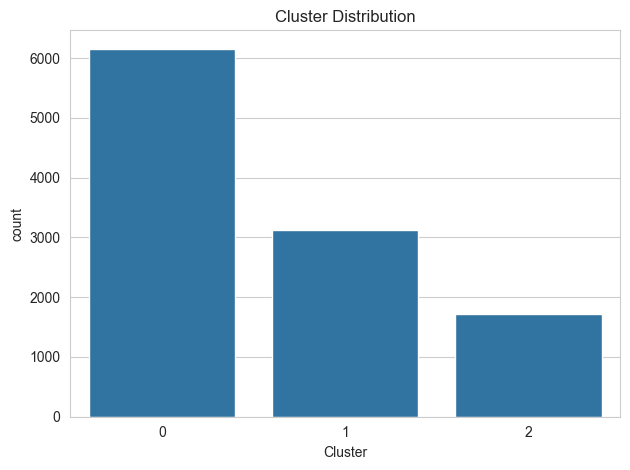

In [6]:
sns.countplot(x=df['Cluster'])
plt.title("Cluster Distribution")
plt.tight_layout()
plt.show()

## 5. SelectKBest Feature Selection

Uses the **ANOVA F-statistic** (`f_classif`) to rank features by how well they separate the two target classes (`Reached.on.Time_Y.N`). The top 5 features are selected.

> **Note:** `ID` and `Cluster` are included in `X_features` intentionally to demonstrate that the selector ranks them objectively alongside domain features.

In [7]:
X_features = df.drop(['Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

# Encode any remaining categorical columns
X_features = pd.get_dummies(X_features, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X_features, y)

selected_features = X_features.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['ID', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms',
       'Cluster'],
      dtype='str')


### 5.1 Feature Score Visualisation

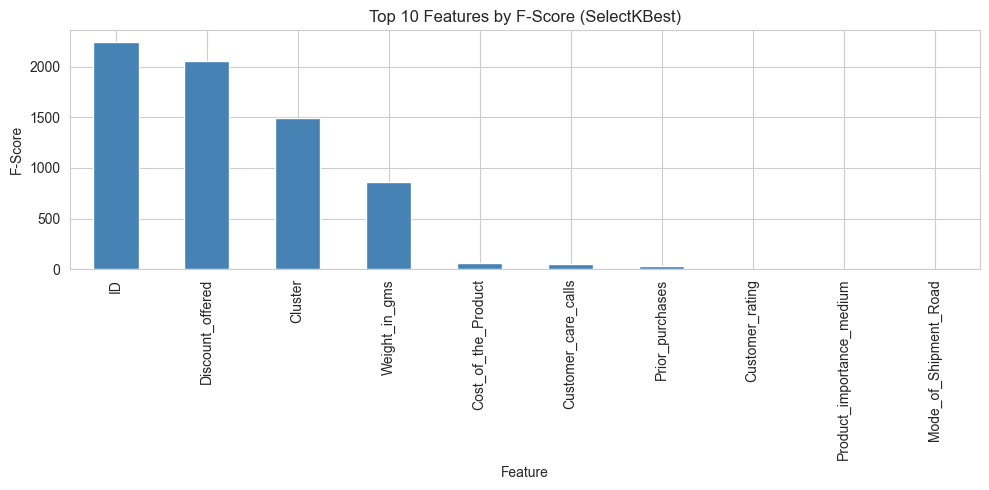

In [8]:
scores = pd.Series(selector.scores_, index=X_features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
scores.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Features by F-Score (SelectKBest)")
plt.ylabel("F-Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()